# CIFAR-10H Data Exploration

This notebook walks through the dataset, sanity checks, and generates the mandatory data-stage plots.

In [2]:
import warnings
warnings.filterwarnings("ignore", category=Warning, message=".*align.*")

In [3]:
%matplotlib inline
import sys
sys.path.append("..")
from data.pipeline import load_full_dataset, run_sanity_checks
from data.statistics import compute_all_statistics
from training.config import FIXED_SEED, PLOTS_DIR
from data import set_seed

set_seed(FIXED_SEED)
dataset = load_full_dataset()
print(f"Dataset size: {len(dataset)}")

✓ Loaded CIFAR-10H dataset: 10000 images
  Soft labels shape: torch.Size([10000, 10])
Dataset size: 10000


In [4]:
# Run all sanity checks
run_sanity_checks(dataset)

🔍 Running sanity checks...
  ✓ Soft labels sum to 1.0: True
  ✓ No NaN/inf values: True
  ✓ Entropy range [0, 3.32]: True
       Min: -0.0000, Max: 2.8602
  ✓ Hard labels in [0, 9]: True
  Sampling 100 images to verify tensor values...
  ✓ Image tensors appear reasonable
✓ All sanity checks passed!


True

In [5]:
stats = compute_all_statistics(dataset)
# Print a summary
print(f"Entropy: mean={stats['entropies'].mean():.3f}, max={stats['entropies'].max():.3f}")


📊 Computing dataset statistics...
  Total samples: 10000
  Entropy range: [-0.0000, 2.8602]
  Mean entropy: 0.2228 bits
  Median entropy: 0.1371 bits
  Majority agreement: 99.2%

  Per-class average entropy:
    Class  0: 0.2511
    Class  1: 0.1282
    Class  2: 0.2531
    Class  3: 0.3547
    Class  4: 0.4016
    Class  5: 0.2268
    Class  6: 0.2010
    Class  7: 0.1082
    Class  8: 0.1517
    Class  9: 0.1519
Entropy: mean=0.223, max=2.860


In [8]:
# Generate all required visualizations
from data.visualization import generate_all_data_visualizations
generate_all_data_visualizations(dataset, stats, save_dir=PLOTS_DIR)


📊 Generating data visualizations...
  ✓ Saved entropy histogram to /Volumes/SSD/DNN/project/notebooks/../outputs/plots/entropy_histogram.png


/Volumes/SSD/DNN/project/notebooks/../data/visualization.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([class_names[c] for c in classes], rotation=45, ha='right')


  ✓ Saved class entropy bar plot to /Volumes/SSD/DNN/project/notebooks/../outputs/plots/class_entropy_bar.png
  ✓ Saved confusion matrix to /Volumes/SSD/DNN/project/notebooks/../outputs/plots/annotator_confusion_matrix.png
  ✓ Saved extreme examples grid to /Volumes/SSD/DNN/project/notebooks/../outputs/plots/extreme_examples_grid.png
✓ All visualizations saved to /Volumes/SSD/DNN/project/notebooks/../outputs/plots/


The plots are saved in `../outputs/plots/`. You can display them inline or open externally.

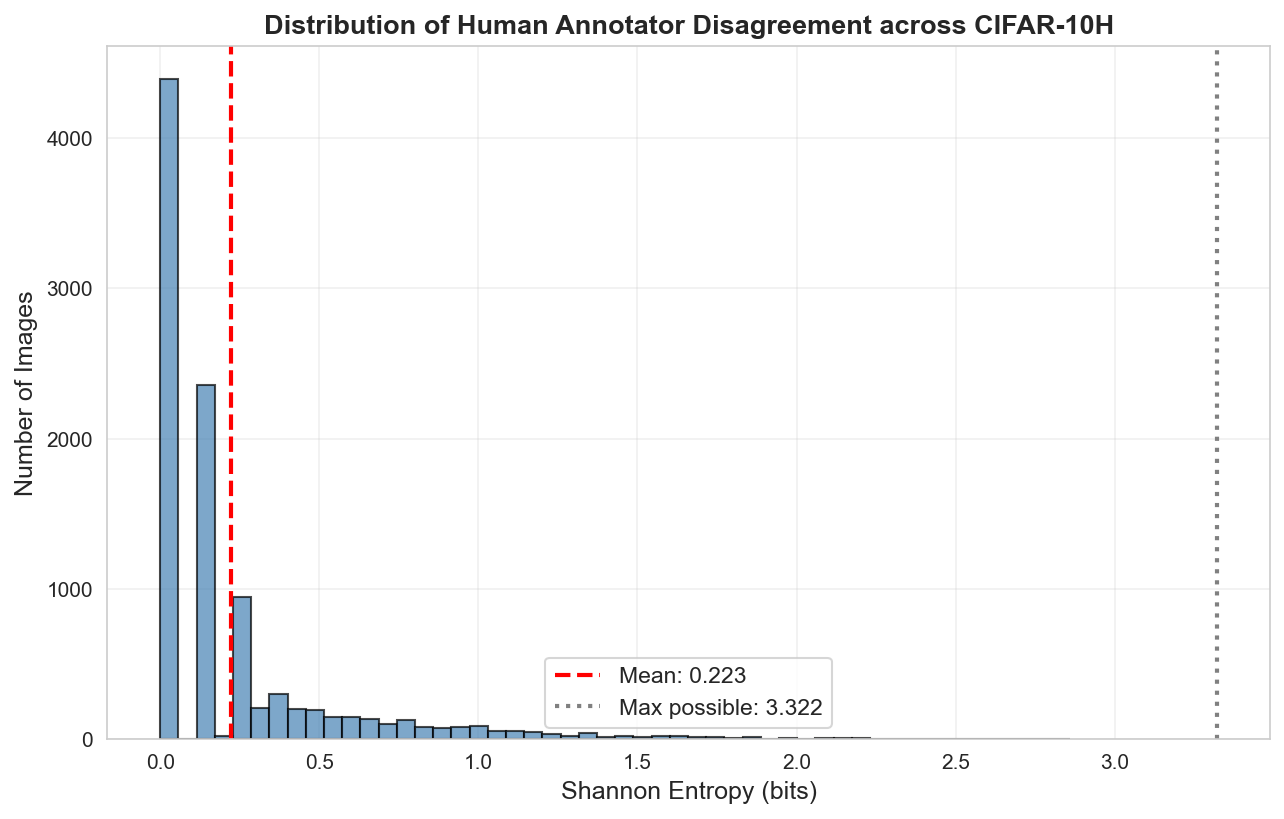

In [7]:
from IPython.display import Image
Image("../outputs/plots/entropy_histogram.png")